# Clase 9: Simular un portafolio usando MGB

## Objetivo de la sesión

Introducir la simulación de un portafolio con datos reales de mercado y comprender el supuesto de normal multivariada en los retornos.

Al finalizar la sesión el estudiante deberá poder:

- Descargar y procesar datos históricos de activos financieros
- Calcular retornos, medias y matriz de covarianza
- Interpretar correlación entre activos
- Comprender el supuesto de normal multivariada
- Simular trayectorias de un portafolio con Monte Carlo
- Analizar la distribución futura del portafolio

Esta sesión conecta la teoría de modelos estocásticos con datos reales de mercado.

---

# 1. De un activo individual a un portafolio

Hasta ahora se ha trabajado con un solo activo simulado.
Sin embargo, en la práctica financiera los inversionistas mantienen portafolios compuestos por múltiples activos.

El valor de un portafolio depende de:

- los retornos individuales de cada activo
- la volatilidad de cada activo
- la relación entre ellos (correlación)

Usar la correlación es importante pues implica que los activos no se mueven de forma independiente.

---

# 2. Supuesto de normal multivariada

[Distribución normal multivariada en Wikipedia](https://es.wikipedia.org/wiki/Distribuci%C3%B3n_normal_multivariada)

Para simular la evolución conjunta de varios activos se asume que el vector de retornos diarios sigue una distribución normal multivariada.

Esto implica que:

- Cada activo tiene una distribución aproximadamente normal
- Los activos presentan correlación entre sí
- Los movimientos conjuntos respetan la matriz de covarianza histórica

En términos formales:
$r \sim N(\mu, \Sigma)$

donde:

- $(r)$ es el vector de retornos
- $(\mu)$ es el vector de medias
- $(\Sigma)$ es la matriz de covarianza

La matriz de covarianza contiene:

- varianzas individuales
- covarianzas entre activos
- estructura completa de dependencia

Este supuesto permite generar escenarios futuros realistas del portafolio más cercanos a la realidad.

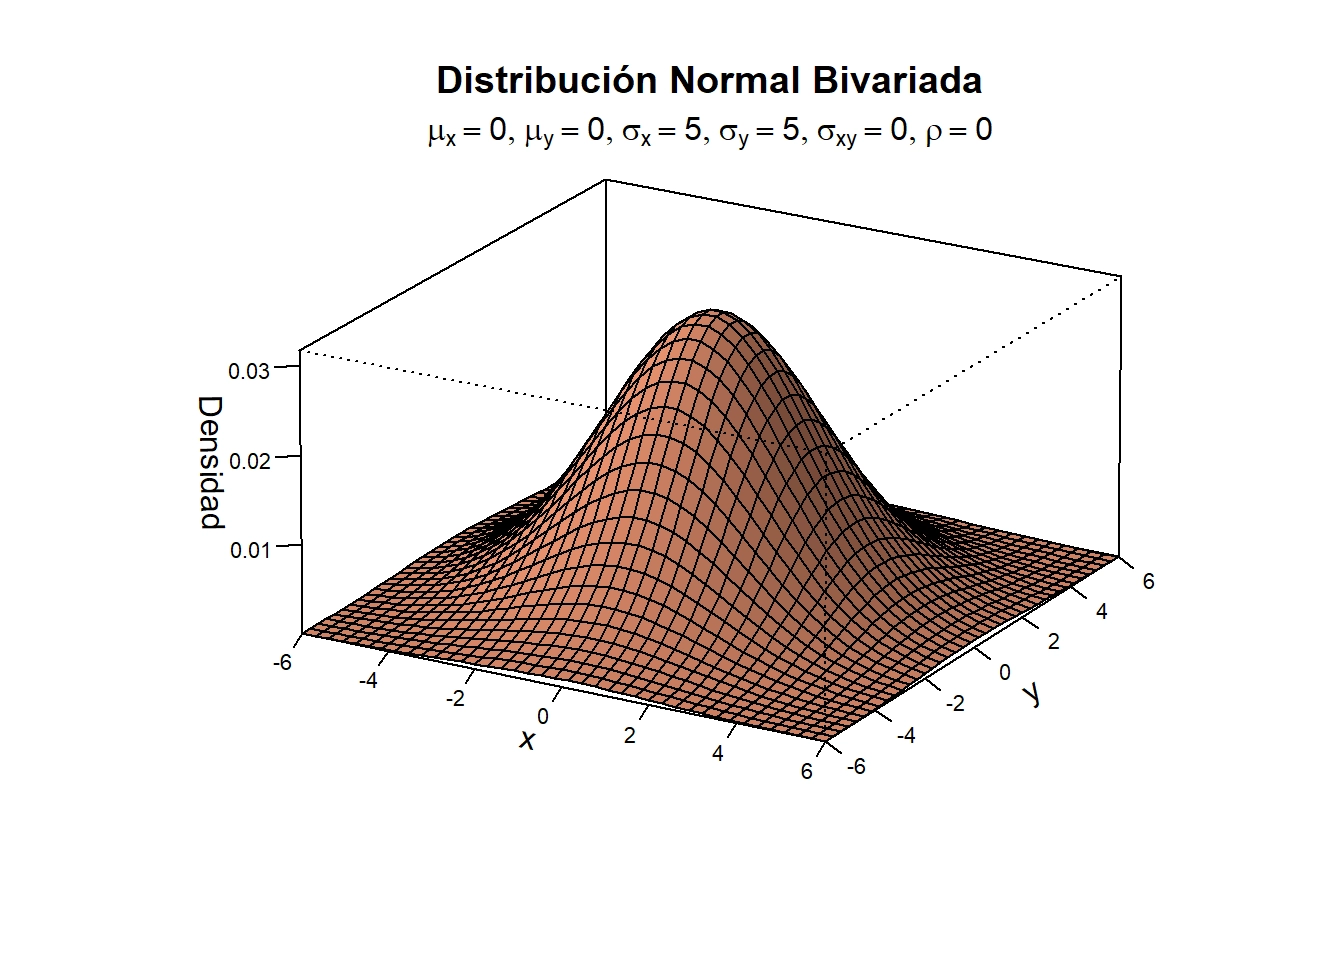

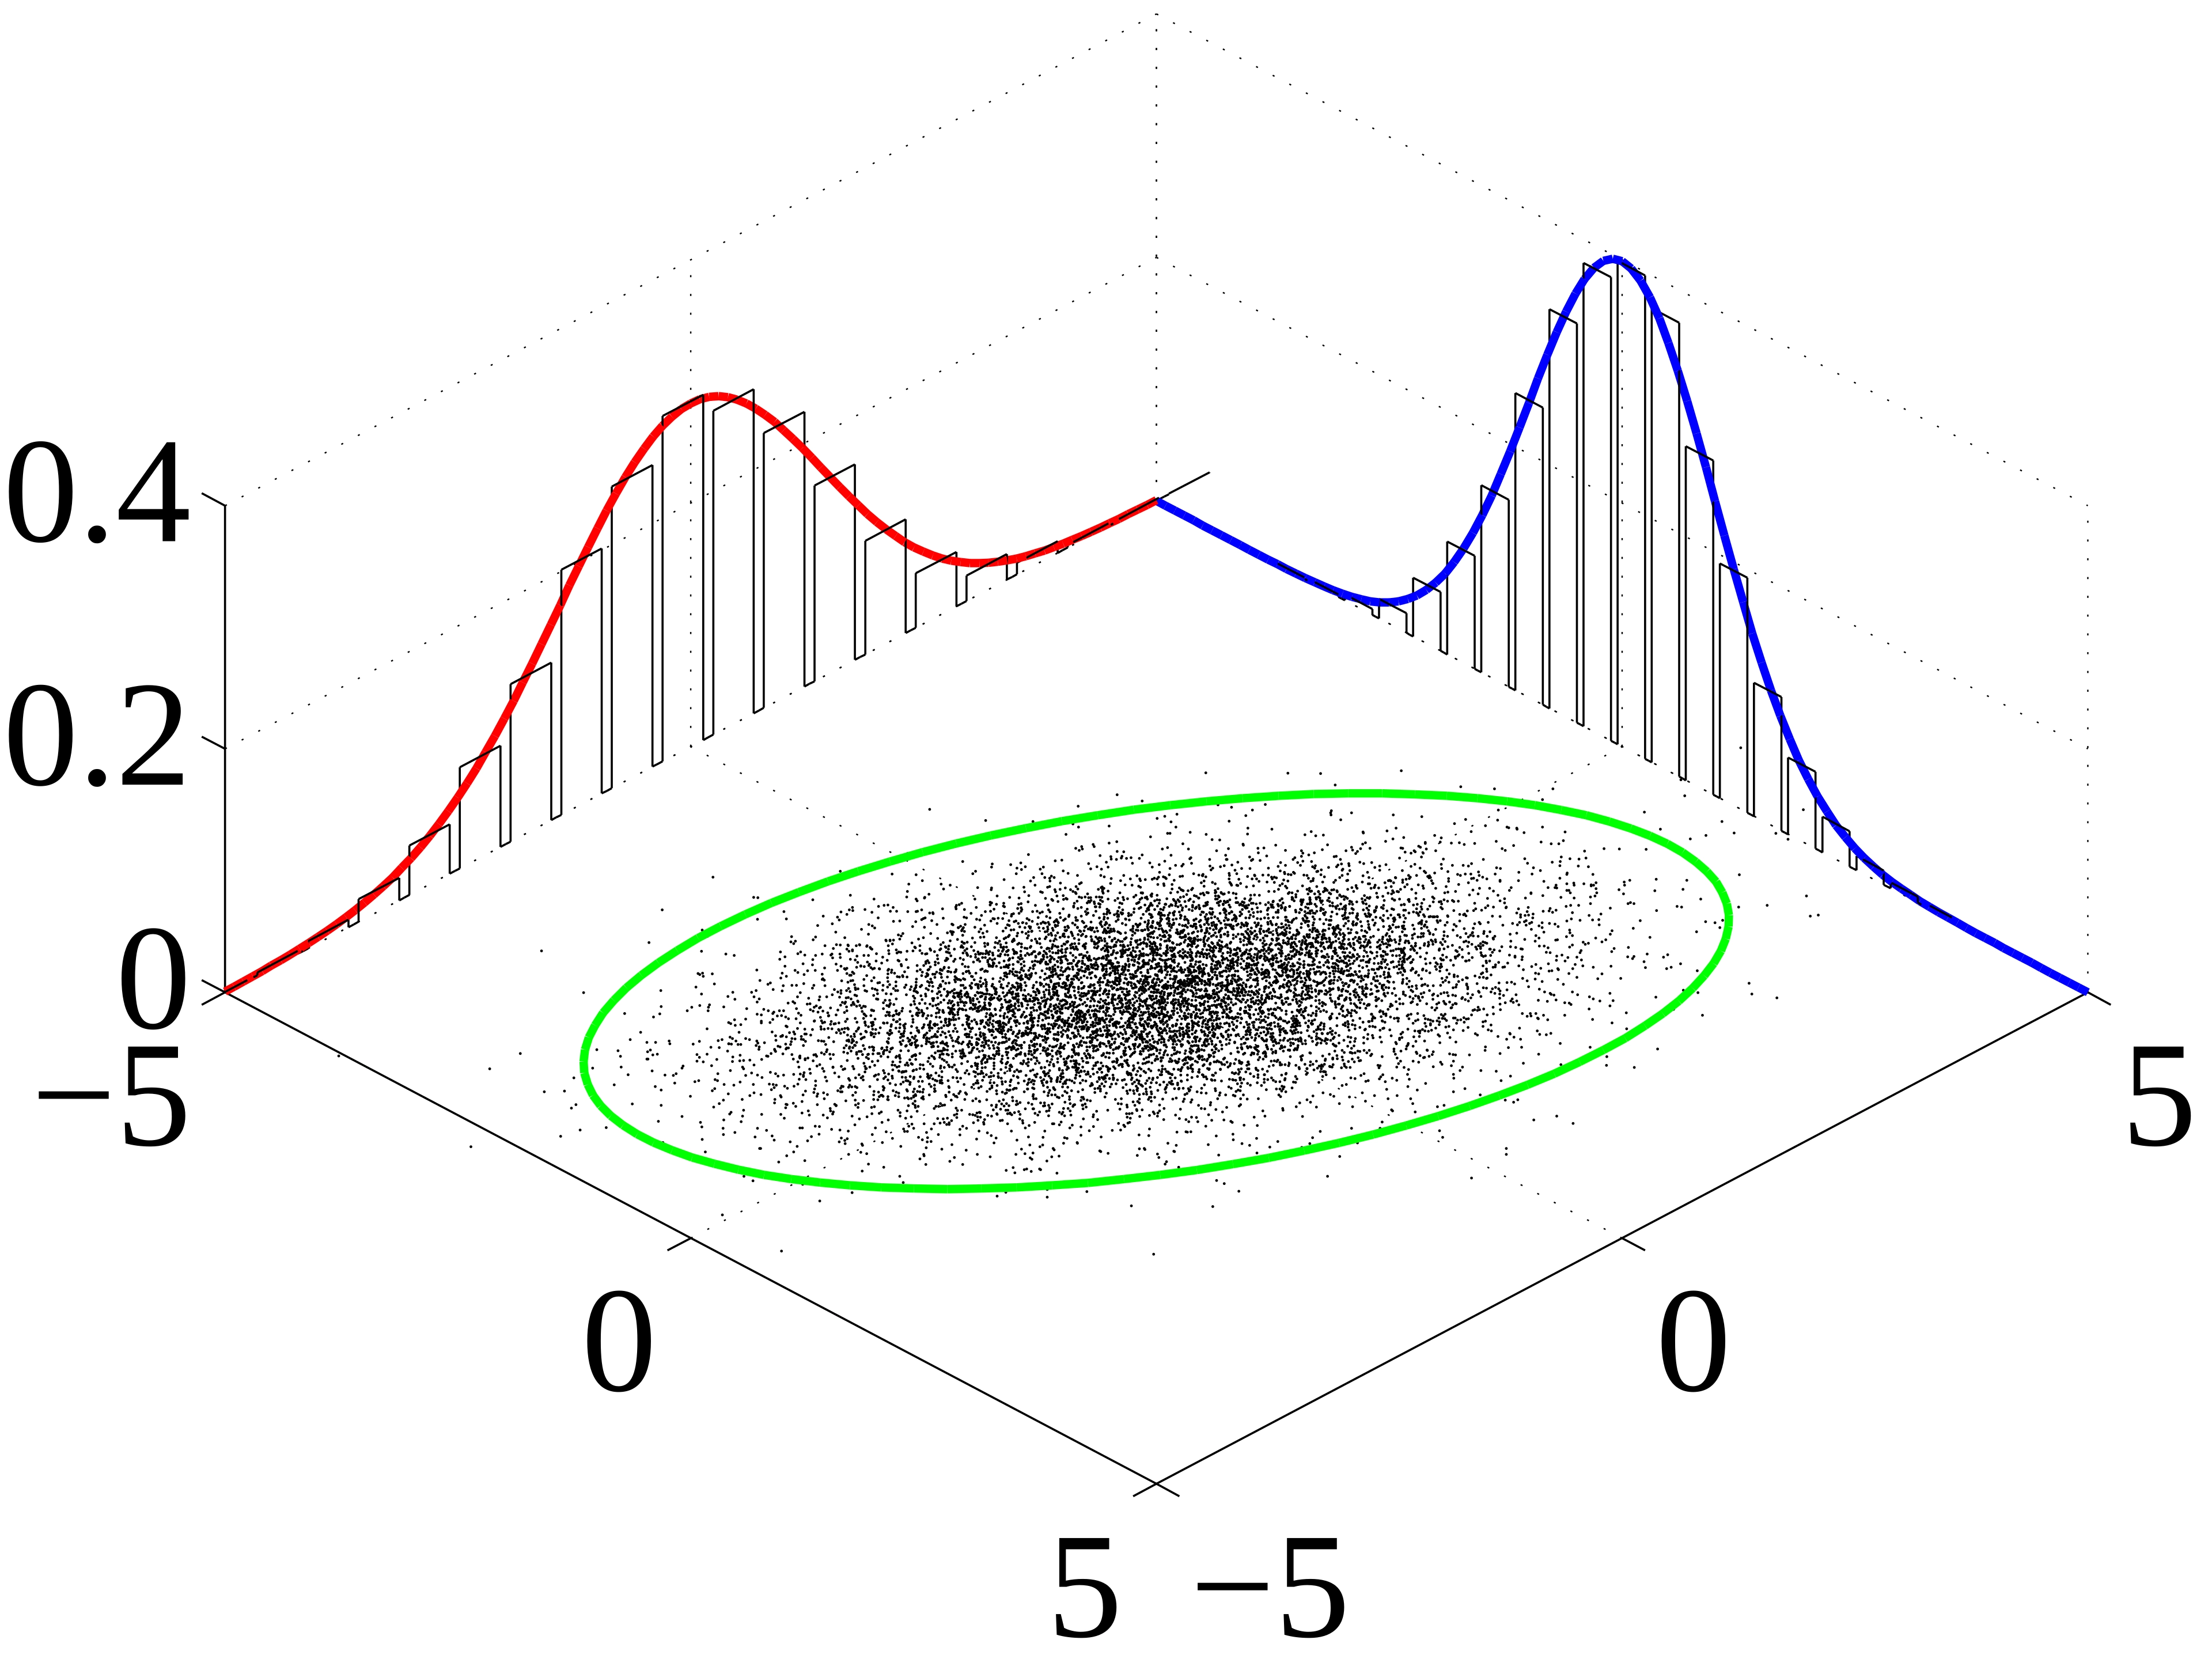

# 3. Importancia de la correlación

Si los activos fueran independientes, el riesgo del portafolio sería menor.
Pero en la práctica los activos suelen moverse de forma conjunta.

En periodos de mercado adversos:

- muchos activos caen simultáneamente
- la diversificación se reduce
- el riesgo del portafolio aumenta

Por esta razón, la simulación debe preservar la correlación histórica entre activos.

---

# 4. Simulación Monte Carlo del portafolio

La simulación Monte Carlo permite generar múltiples trayectorias posibles del valor del portafolio utilizando:

- medias históricas
- matriz de covarianza
- shocks aleatorios normales correlacionados

Cada simulación representa un escenario futuro posible.

Al repetir miles de simulaciones se obtiene una distribución de resultados del portafolio.

# 5. Implementación en Python

## Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import datetime as dt

## Parámetros del portafolio

In [2]:
stocks = ["AAPL","MSFT","NVDA","AMZN"]
weights = np.array([0.25,0.25,0.25,0.25])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*3)

## Descarga de precios históricos

In [3]:
prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

Media diaria retornos:
Ticker
AAPL    0.000917
AMZN    0.001201
MSFT    0.000741
NVDA    0.003407
dtype: float64
\nMatriz de covarianza:
Ticker      AAPL      AMZN      MSFT      NVDA
Ticker                                        
AAPL    0.000263  0.000144  0.000106  0.000179
AMZN    0.000144  0.000387  0.000167  0.000272
MSFT    0.000106  0.000167  0.000221  0.000237
NVDA    0.000179  0.000272  0.000237  0.000967


Esto permite observar tendencias, volatilidad y diferencias de escala entre activos.

---

## Correlación entre activos

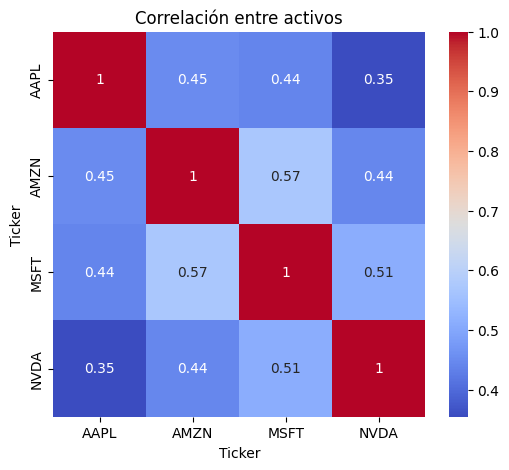

In [4]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

La matriz de correlación muestra qué activos tienden a moverse juntos.

---

## Retornos históricos del portafolio

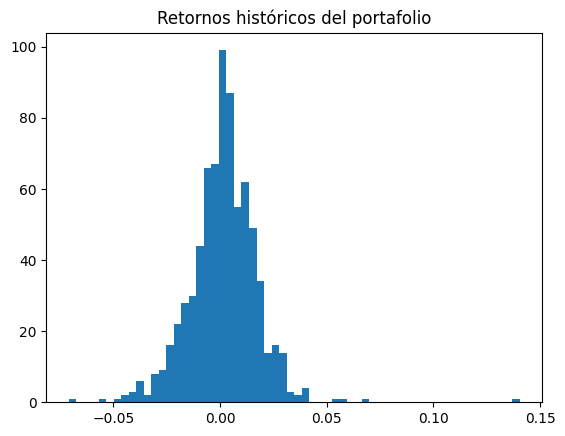

Volatilidad histórica diaria: 0.01589839947692427


In [5]:
portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())

Esto permite comparar el comportamiento histórico del portafolio con las simulaciones futuras.

---

# 6. Simulación Monte Carlo multivariada

## Parámetros de simulación

In [6]:
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

La descomposición de Cholesky se utiliza para introducir la correlación entre los shocks.

---

## Simulación de trayectorias

In [7]:
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

Cada iteración genera una trayectoria posible del valor del portafolio.

---

# 7. Visualización de trayectorias

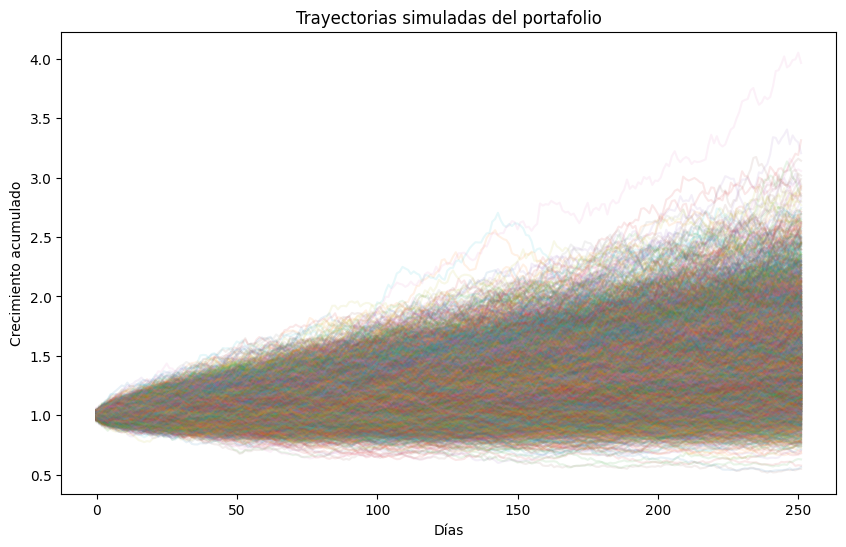

In [8]:
plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

Las trayectorias muestran la incertidumbre sobre el valor futuro del portafolio.

---

# 8. Distribución final del portafolio

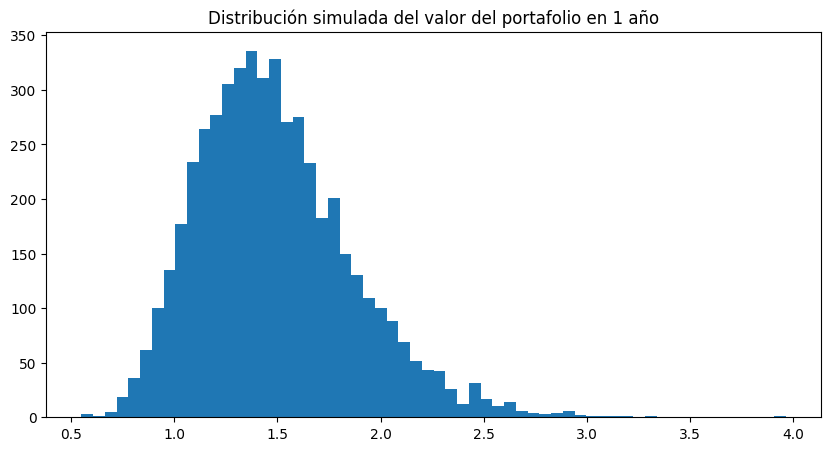

Valor esperado final: 1.488453998599307
Probabilidad de pérdida: 0.0702


In [9]:
final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))

Esta distribución representa todos los escenarios posibles al final del horizonte.

Cada punto del histograma corresponde a un escenario simulado.

---

# 9. Cierre

La simulación produce una distribución de posibles valores futuros del portafolio.

Esto permite analizar:

- dispersión de resultados
- probabilidad de pérdida
- escenarios favorables
- escenarios adversos

Un modelo estocástico no genera una predicción única, sino una distribución completa de posibles resultados.

El análisis del riesgo financiero se basa precisamente en el estudio de esta distribución.

## ACTIVIDAD - Simulación Monte Carlo con portafolio real 

1. Construcción del portafolio con datos reales
Seleccionar entre 3 y 5 activos financieros disponibles en Yahoo Finance (distintos a los usados en clase).

El código debe:

- Descargar precios históricos (al menos 2 años)

- Calcular retornos diarios

- Calcular la media de retornos

- Calcular la matriz de covarianza

- Definir un portafolio con pesos que sumen 1

- Graficar los precios históricos de los activos seleccionados

El estudiante puede elegir libremente los activos.

2. Exploración de datos del portafolio
A partir de los datos históricos:

Graficar la matriz de correlación entre activos

Graficar la distribución de retornos del portafolio

Calcular el retorno promedio del portafolio

Calcular la volatilidad histórica del portafolio

 

Responder brevemente en comentarios dentro del código:

¿Qué activos están más correlacionados?

¿El portafolio parece estable o muy variable?

¿Cuál activo parece dominar el comportamiento del portafolio?

3. Simulación Monte Carlo del portafolio
Implementar una simulación Monte Carlo para el portafolio.

El código debe:

- Usar media y matriz de covarianza históricas

- Simular al menos 5,000 trayectorias

- Simular al menos 252 días hacia adelante

- Generar choques normales correlacionados

 

Generar las siguientes gráficas:

Trayectorias simuladas del portafolio

Distribución del valor final del portafolio

4. Análisis de la simulación
Calcular e imprimir:

Valor promedio final del portafolio

Valor máximo observado

Valor mínimo observado

 

Responder en comentarios en Markdown:

¿Las trayectorias simuladas son similares entre sí o muy distintas?

¿La dispersión aumenta con el tiempo?

¿Qué observas en la distribución final del portafolio?

5. Exploración libre 
Modificar al menos uno de los siguientes elementos para generar un nuevo portafolio:

Cambiar los activos del portafolio

Cambiar los pesos

Cambiar el horizonte temporal 

Compara tus resultados con el portafolio anterior y agregar reflexiona:

¿Qué observas al modificar el portafolio o el horizonte?

El objetivo es experimentar con el modelo y observar cómo cambian las simulaciones.



In [18]:
# Parametros portafolio 
stocks = ['PLTR','GLD','TSLA','JNJ']
weights = np.array([0.3,0.1,0.4,0.2])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*3)

stocks

['PLTR', 'GLD', 'TSLA', 'JNJ']

In [19]:
# Descarga de datos históricos 

prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

Media diaria retornos:
Ticker
GLD     0.001360
JNJ     0.000747
PLTR    0.004508
TSLA    0.001651
dtype: float64
\nMatriz de covarianza:
Ticker       GLD       JNJ      PLTR      TSLA
Ticker                                        
GLD     0.000139  0.000007  0.000036  0.000005
JNJ     0.000007  0.000117 -0.000036 -0.000024
PLTR    0.000036 -0.000036  0.001708  0.000632
TSLA    0.000005 -0.000024  0.000632  0.001362


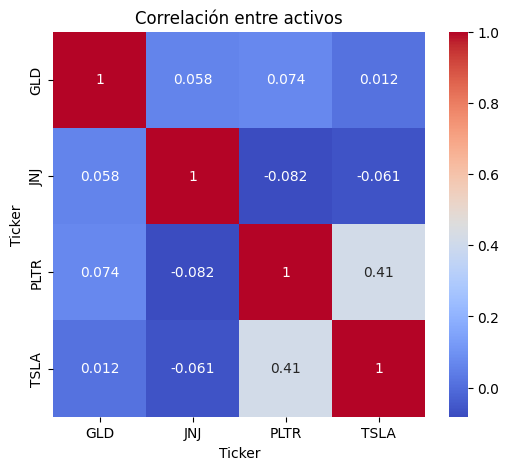

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

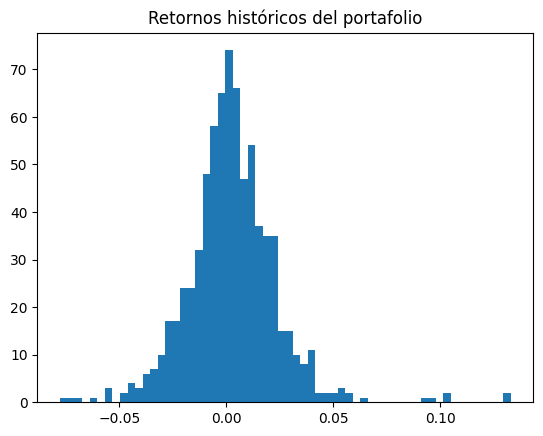

Volatilidad histórica diaria: 0.02117161691052744


In [21]:
# Retornos históricos 

portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())

In [22]:
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

In [23]:
# Simulación de trayectorias 

for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

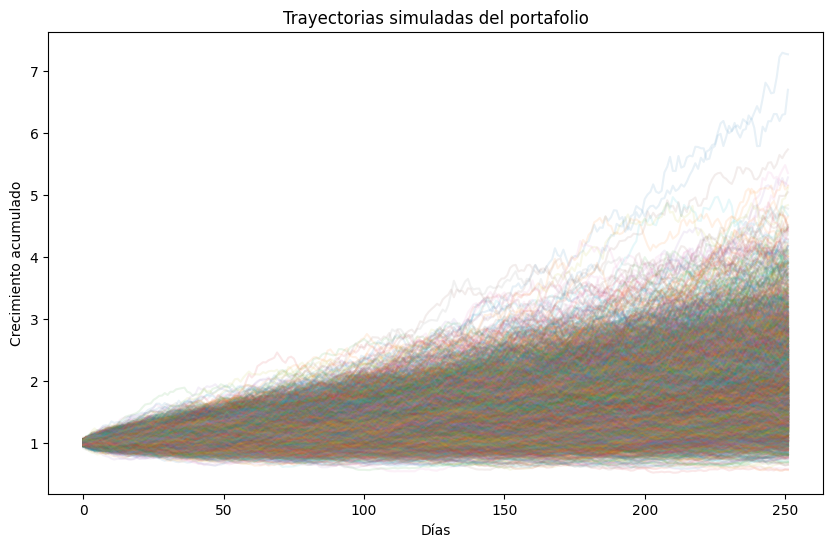

In [24]:
# Visualiación trayectorias 

plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

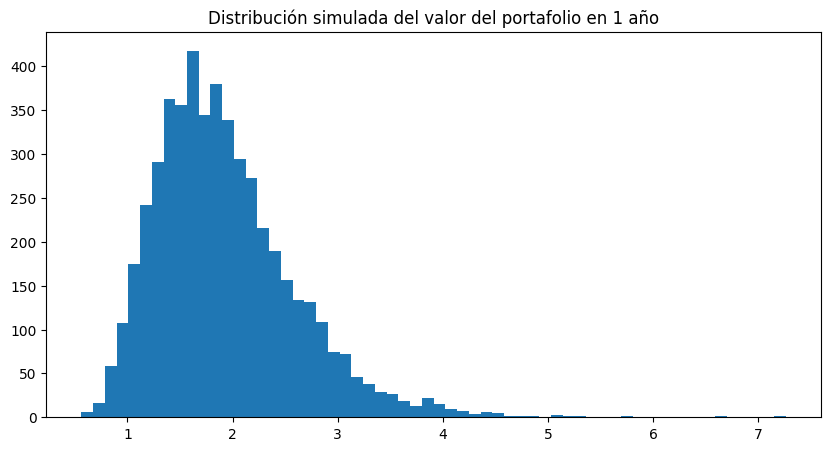

Valor esperado final: 1.9278767998933763
Probabilidad de pérdida: 0.0362


In [25]:
# Distribución del portafolio 

final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))

### Respuestas:


- **¿Las trayectorias simuladas son similares entre sí o muy distintas?:** Las trayectorias son muy similares entre sí.

- **¿La dispersión aumenta con el tiempo?:** Si va aumentando y se puede observar que entre más tiempo pasa más incertidumbre hay.

- **¿Qué observas en la distribución final del portafolio?:** Observo que tiene un sesgo positivo, pues está más inclinado a la izquierda y su cola más fuerte a la derecha.